In [1]:
# #Mount Google Drive
# from google.colab import drive
# drive.mount('/content/drive')
# %cd "/content/drive/MyDrive/DL_Lab5/"

In [2]:
# unzip the file
!tar zxvf cifar100.tar.gz

x cifar100/
x cifar100/train.pt
x cifar100/valid.pt


In [3]:
# !pip install efficientnet_pytorch
# !pip install --upgrade efficientnet-pytorch

In [4]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data.dataloader import DataLoader
import matplotlib.pyplot as plt
import numpy as np

In [5]:
train_set = torch.load("cifar100/train.pt")
valid_set = torch.load("cifar100/valid.pt")

batch_size = 128
train_loader = DataLoader(train_set, batch_size, shuffle=False)
valid_loader = DataLoader(valid_set, batch_size, shuffle=False)

C:\Users\User\AppData\Local\Temp\ipykernel_24176\1421259312.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  train_set = torch.load("cifar100/train.pt")
C:\Users\User\App

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.3159098..1.5126765].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.7669962..1.5126765].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.4258603..1.2893678].


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.44108856..1.498473].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.23434603..1.2783198].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.39522225..1.362668].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.37993348..1.113447].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.4487329..1.4088521].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.41051102..1.5126765].


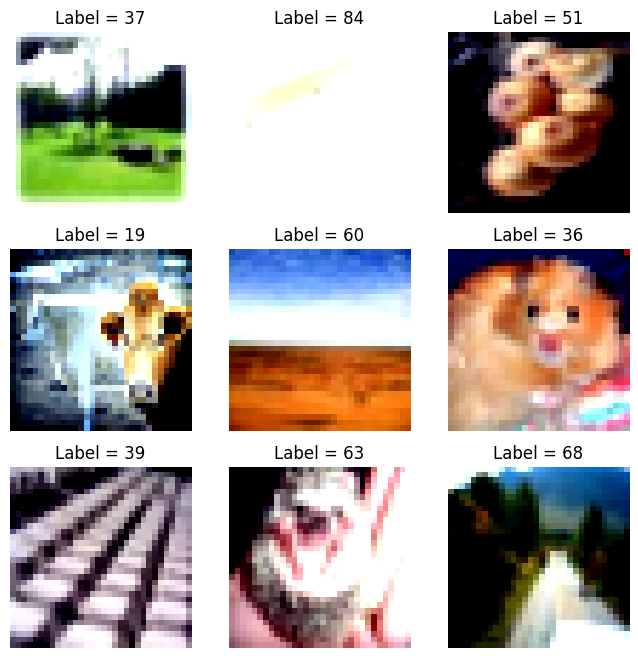

In [6]:
## show the read pictures randomly
figure = plt.figure(figsize=(8, 8))
cols, rows = 3, 3
for i in range(1, cols * rows + 1):
    sample_idx = torch.randint(len(train_set), size=(1,)).item()
    img = train_set[sample_idx][0].numpy().transpose(1, 2, 0)
    label = train_set[sample_idx][1]
    ax = figure.add_subplot(rows, cols, i)
    ax.set_title("Label = {}".format(label))
    plt.axis("off")

    img = img / 2 + 0.5

    plt.imshow(img.squeeze())
plt.show()

# Model

In [ ]:

import torch
import torch.nn as nn
import torch.optim as optim
# from efficientnet_pytorch import EfficientNet
from torchvision.models import shufflenet_v2_x0_5, ShuffleNet_V2_X0_5_Weights
# using gpu if available
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

#build your model here
class CIFAR100ShuffleNet(nn.Module):
    def __init__(self, num_classes=100,dropout_prob=0.2):
        super(CIFAR100ShuffleNet, self).__init__()
        # 1. 加載預訓練權重
        weights = ShuffleNet_V2_X0_5_Weights.IMAGENET1K_V1
        self.base_model = shufflenet_v2_x0_5(weights=weights) 
        # 2. 添加Dropout層
        self.dropout = nn.Dropout(p=dropout_prob)
         # 3. 修改分類層
        self.base_model.fc = nn.Linear(1024, num_classes) 
    
    def forward(self, x):
        x = self.base_model(x)
        x = self.dropout(x)
        return x
        # return self.base_model(x)
    
#call model
model = CIFAR100ShuffleNet().to(DEVICE)
criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=0.001, weight_decay=0.01)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=100)

In [8]:
####################  Training Phase  ###################################
def train_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for inputs, targets in loader:
        inputs, targets = inputs.to(device), targets.to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, targets)

        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = outputs.max(1)
        total += targets.size(0)
        correct += predicted.eq(targets).sum().item()

    epoch_loss = running_loss / len(loader)
    accuracy = 100. * correct / total
    return epoch_loss, accuracy


Epoch 1/150
Train Loss: 3.678 | Train Acc: 17.93%
Valid Loss: 2.738 | Valid Acc: 32.46%
Saving model...

Epoch 2/150
Train Loss: 2.937 | Train Acc: 29.97%
Valid Loss: 2.360 | Valid Acc: 40.11%
Saving model...

Epoch 3/150
Train Loss: 2.691 | Train Acc: 35.37%
Valid Loss: 2.175 | Valid Acc: 43.87%
Saving model...

Epoch 4/150
Train Loss: 2.507 | Train Acc: 39.22%
Valid Loss: 2.018 | Valid Acc: 47.28%
Saving model...

Epoch 5/150
Train Loss: 2.365 | Train Acc: 42.44%
Valid Loss: 1.897 | Valid Acc: 49.82%
Saving model...

Epoch 6/150
Train Loss: 2.235 | Train Acc: 45.41%
Valid Loss: 1.809 | Valid Acc: 51.93%
Saving model...

Epoch 7/150
Train Loss: 2.128 | Train Acc: 47.89%
Valid Loss: 1.725 | Valid Acc: 54.26%
Saving model...

Epoch 8/150
Train Loss: 2.015 | Train Acc: 50.85%
Valid Loss: 1.637 | Valid Acc: 56.41%
Saving model...

Epoch 9/150
Train Loss: 1.899 | Train Acc: 53.72%
Valid Loss: 1.577 | Valid Acc: 57.72%
Saving model...

Epoch 10/150
Train Loss: 1.801 | Train Acc: 56.04%
Val

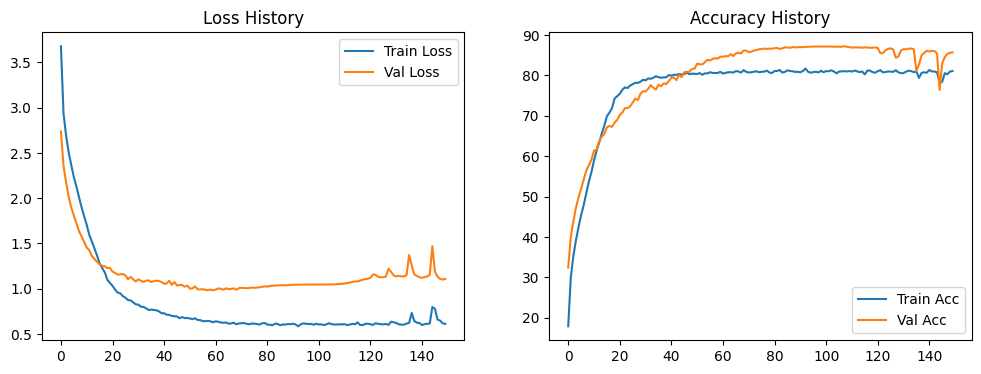

In [9]:
####################  Validation Phase  ###################################
def validate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for inputs, targets in loader:
            inputs, targets = inputs.to(device), targets.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, targets)

            running_loss += loss.item()
            _, predicted = outputs.max(1)
            total += targets.size(0)
            correct += predicted.eq(targets).sum().item()

    val_loss = running_loss / len(loader)
    accuracy = 100. * correct / total
    return val_loss, accuracy

# Training loop
epochs = 150
best_acc = 0
history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

for epoch in range(epochs):
    print(f'\nEpoch {epoch+1}/{epochs}')

    train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, DEVICE)
    val_loss, val_acc = validate(model, valid_loader, criterion, DEVICE)
    scheduler.step()

    print(f'Train Loss: {train_loss:.3f} | Train Acc: {train_acc:.2f}%')
    print(f'Valid Loss: {val_loss:.3f} | Valid Acc: {val_acc:.2f}%')

    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)

    if val_acc > best_acc:
        print('Saving model...')
        torch.save(model, 'model.pth')
        best_acc = val_acc

# Plot results
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history['train_loss'], label='Train Loss')
plt.plot(history['val_loss'], label='Val Loss')
plt.title('Loss History')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history['train_acc'], label='Train Acc')
plt.plot(history['val_acc'], label='Val Acc')
plt.title('Accuracy History')
plt.legend()
plt.show()

In [10]:
# !pip install thop
# !python test.py